<div style="
background-color:#EAEAEA;
padding:15px;
border-left:5px solid #6C757D;
border-radius:6px;">

# Master's Thesis in Advanced Physics
---

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**
June 2026
</div>

# Bahcall EDA - Standard Solar Models and Neutrino Production Profiles
---

This notebook is an Exploratory Data Analysis (EDA) of standard solar model
and solar-neutrino production data downloaded from John Bahcall's public
**[Solar Neutrino Software and Data](https://www.sns.ias.edu/~jnb/SNdata/sndata.html)**
page and stored locally under `data/external/Bahcall`.

Two solar-model generations are covered: 
- **BS2005** (Bahcall, Serenelli & Basu 2005, two abundance variants: AGS,OP and OP) a
- **BP2004** (Bahcall & Pinsonneault 2004).

For each model the local files give:
- The radial structure of the Sun (temperature, density, composition).
- The electron density profile needed for MSW matter effects.
- The fraction of each solar neutrino species produced in every radial shell 

**Notes:**
- fraction of each solar neutrino species corresponds exactly with the "solar neutrino production" distributions that the `medium.solar` module consumes
- Zenodo Database, `notebooks/external/zenodo/zenodo_solar_models.ipynb`, uses the newer B16-AGSS09 generation.

---

## Table of Contents

| # | Section |
|---|---------|
| [0](#0.-Dataset-and-Physics-Context) | **Dataset and Physics Context**: source, files, physics, references |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Raw-Data-Inventory) | **Raw Data Inventory** |
| [4](#4.-Standard-Solar-Model-Structure) | **Standard Solar Model Structure**: temperature/density (4.1), composition (4.2) |
| [5](#5.-Electron-Density-Profile) | **Electron Density Profile**: dedicated file (5.1), cross-check (5.2) |
| [6](#6.-Solar-Neutrino-Production-Point-Distributions) | **Solar Neutrino Production-Point Distributions**: pp/8B (6.1), Be7/pep/CNO/hep (6.2) |
| [7](#7.-Total-Flux-Normalizations) | **Total Flux Normalizations** |
| [8](#8.-Cross-Model-Comparison-Summary) | **Cross-Model Comparison Summary** |
| [9](#9.-Summary) | **Summary** |


## 0. Dataset and Physics Context

### 0.1 Source of the Data

The files analysed here come from John Bahcall's public page
**[Solar Neutrino Software and Data](https://www.sns.ias.edu/~jnb/SNdata/sndata.html)**
(`sns.ias.edu/~jnb`, Institute for Advanced Study), specifically the `Export`
subdirectories for the BS2005 and BP2004 standard solar models. The local
directory `data/external/Bahcall` contains:

| Local file | Model | Description from the data page |
|---|---|---|
| `bs05_agsop.dat` | BS2005(AGS,OP) | Standard solar model: mass fraction, radius, T, rho, P, luminosity, composition by shell |
| `bs05op.dat` | BS2005(OP) | Same, older Grevesse-Sauval abundances instead of Asplund et al. |
| `bs2005agsopflux.dat` | BS2005(AGS,OP) | Fraction of each neutrino flux produced per shell, plus T, log(n_e), 7Be mass fraction |
| `bs2005opflux.dat` | BS2005(OP) | Same, for the OP abundance variant |
| `nele_bs05op.dat` | BS2005(OP) | Dedicated electron density profile, log10(n_e/N_A) vs R/Rsun |
| `bp2004stdmodel.dat` | BP2004 | Standard solar model, same column layout as the BS2005 files |
| `bp2004flux.dat` | BP2004 | Fraction of each neutrino flux produced per shell |

### 0.2 Physics Content

A standard solar model (SSM) integrates the equations of stellar structure
(hydrostatic equilibrium, energy transport, nuclear energy generation) under
constraints from observed luminosity, radius, age, and helioseismology, to
predict the Sun's internal temperature, density, and composition profiles.
The competing element-abundance determinations behind the "AGS,OP" (Asplund,
Grevesse, Sauval) versus "OP" (Grevesse-Sauval, Opacity Project) variants were,
historically, at the centre of the "solar abundance problem": lower
photospheric heavy-element abundances improved agreement with certain stellar
spectroscopy but worsened agreement with helioseismic sound-speed profiles.

Solar neutrinos are produced by different fusion reactions (pp, pep, hep, 7Be,
8B in the pp-chain; 13N, 15O, 17F in the CNO cycle) that occur predominantly
in the Sun's core, but not all at exactly the same radius: hotter, more
temperature-sensitive reactions (8B, CNO) are more centrally concentrated than
the pp reaction. The production-point distributions in Section 6 give,
shell by shell, what fraction of each species' total flux originates there --
directly analogous to the `radius`/`production_fraction(source)` tables
consumed by `tpeanuts.medium.solar.probability.solar_flux_mass` (see
`data/solar/flux/nudistr_zenodo_SF3_AGSS09.csv` for the newer B16-AGSS09
generation used elsewhere in this project). The electron density profile
(Section 5) is the other key solar-model ingredient: it sets the MSW matter
potential a neutrino experiences while leaving its production point.

### 0.3 Reference Articles

- J. N. Bahcall, A. M. Serenelli, S. Basu, **New Solar Opacities, Abundances,
  Helioseismology, and Neutrino Fluxes**, *The Astrophysical Journal*
  **621**, L85 (2005), DOI:
  [10.1086/428929](https://doi.org/10.1086/428929), arXiv:
  [astro-ph/0412440](https://arxiv.org/abs/astro-ph/0412440). (BS2005 models)
- J. N. Bahcall, M. H. Pinsonneault, **What Do We (Not) Know Theoretically
  about Solar Neutrino Fluxes?**, *Physical Review Letters* **92**, 121301
  (2004), DOI:
  [10.1103/PhysRevLett.92.121301](https://doi.org/10.1103/PhysRevLett.92.121301),
  arXiv: [astro-ph/0402114](https://arxiv.org/abs/astro-ph/0402114). (BP2004 model)
- Dataset: J. N. Bahcall, *Solar Neutrino Software and Data*,
  [https://www.sns.ias.edu/~jnb/SNdata/sndata.html](https://www.sns.ias.edu/~jnb/SNdata/sndata.html)
  (Institute for Advanced Study, accessed for this thesis).


## 1. Libraries

In [1]:
from __future__ import annotations

import re
from pathlib import Path

from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show

print(f"pandas {pd.__version__}   numpy {np.__version__}")

pandas 2.3.3   numpy 1.26.4


## 2. Paths and Configuration

### 2.1 Paths

The input directory is `data/external/Bahcall`. The output directory follows
the notebook's location relative to `notebooks/`, so generated figures are
saved under `external/bahcall` in the configured notebook output root.

**Expected results:** all seven local files should exist.

In [2]:
config = load_notebook_config()
BAHCALL_DATA_DIR = config.external_data_dir / "Bahcall"
OUTPUT_DIR = config.output_dir("external", "bahcall")
SHOW_PLOTS = config.show_plots

FILES = {
    "bs05_agsop_model": BAHCALL_DATA_DIR / "bs05_agsop.dat",
    "bs05op_model": BAHCALL_DATA_DIR / "bs05op.dat",
    "bs05_agsop_flux": BAHCALL_DATA_DIR / "bs2005agsopflux.dat",
    "bs05op_flux": BAHCALL_DATA_DIR / "bs2005opflux.dat",
    "bs05op_nele": BAHCALL_DATA_DIR / "nele_bs05op.dat",
    "bp2004_model": BAHCALL_DATA_DIR / "bp2004stdmodel.dat",
    "bp2004_flux": BAHCALL_DATA_DIR / "bp2004flux.dat",
}

print(f"Repository root      : {config.package_dir}")
print(f"Bahcall data directory: {BAHCALL_DATA_DIR}")
print(f"Figure output dir     : {OUTPUT_DIR}")
for key, path in FILES.items():
    print(f"  {key:18s} {path.name:24s} exists={path.exists()}  size={path.stat().st_size if path.exists() else 0} bytes")

Repository root      : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Bahcall data directory: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\external\Bahcall
Figure output dir     : v:\output\external\bahcall
  bs05_agsop_model   bs05_agsop.dat           exists=True  size=158748 bytes
  bs05op_model       bs05op.dat               exists=True  size=156775 bytes
  bs05_agsop_flux    bs2005agsopflux.dat      exists=True  size=152322 bytes
  bs05op_flux        bs2005opflux.dat         exists=True  size=152314 bytes
  bs05op_nele        nele_bs05op.dat          exists=True  size=52115 bytes
  bp2004_model       bp2004stdmodel.dat       exists=True  size=132540 bytes
  bp2004_flux        bp2004flux.dat           exists=True  size=78214 bytes


### 2.2 Local Helpers

Every file in this dataset mixes free-text headers, a column-description
block, and a fixed-width numeric table, with slightly different header
lengths from file to file. Rather than hardcoding a skip-row count per file,
`read_numeric_table` scans every line and keeps only the ones that parse as
exactly `ncols` floats -- robust to each file's specific header/footer
wording. `read_cumulative_fluxes` separately extracts the one-line "cumulative
neutrino fluxes" summary that precedes the per-shell table in the flux
files.

In [3]:
FLUX_SPECIES = ["pp", "8B", "13N", "15O", "17F", "7Be", "pep", "hep"]

MODEL_COLUMNS = ["M_Msun", "R_Rsun", "T_K", "rho_gcm3", "P_dyncm2", "L_Lsun", "X_H1", "Y_He4", "X_He3", "X_C12", "X_N14", "X_O16"]
FLUX_COLUMNS = ["R_Rsun", "T_1e6K", "log10_ne_over_NA", "shell_mass_frac", "X_Be7"] + [f"frac_{s}" for s in FLUX_SPECIES]


def _try_floats(tokens: list[str]) -> list[float] | None:
    try:
        return [float(t) for t in tokens]
    except ValueError:
        return None


def read_numeric_table(path: Path, ncols: int, column_names: list[str]) -> pd.DataFrame:
    rows = []
    for line in path.read_text(encoding="utf-8", errors="replace").splitlines():
        tokens = line.split()
        if len(tokens) != ncols:
            continue
        values = _try_floats(tokens)
        if values is not None:
            rows.append(values)
    if not rows:
        raise ValueError(f"No {ncols}-column numeric rows found in {path}")
    return pd.DataFrame(rows, columns=column_names)


def read_cumulative_fluxes(path: Path) -> pd.Series:
    """Extract the one-line cumulative-flux summary (8 species) from a *flux.dat file."""
    for line in path.read_text(encoding="utf-8", errors="replace").splitlines():
        tokens = line.split()
        if len(tokens) != len(FLUX_SPECIES):
            continue
        values = _try_floats(tokens)
        if values is not None:
            return pd.Series(values, index=FLUX_SPECIES)
    raise ValueError(f"No {len(FLUX_SPECIES)}-value cumulative-flux row found in {path}")


print("Helpers defined: read_numeric_table, read_cumulative_fluxes")
print(f"Model columns ({len(MODEL_COLUMNS)}): {MODEL_COLUMNS}")
print(f"Flux columns ({len(FLUX_COLUMNS)}) : {FLUX_COLUMNS}")

Helpers defined: read_numeric_table, read_cumulative_fluxes
Model columns (12): ['M_Msun', 'R_Rsun', 'T_K', 'rho_gcm3', 'P_dyncm2', 'L_Lsun', 'X_H1', 'Y_He4', 'X_He3', 'X_C12', 'X_N14', 'X_O16']
Flux columns (13) : ['R_Rsun', 'T_1e6K', 'log10_ne_over_NA', 'shell_mass_frac', 'X_Be7', 'frac_pp', 'frac_8B', 'frac_13N', 'frac_15O', 'frac_17F', 'frac_7Be', 'frac_pep', 'frac_hep']


## 3. Raw Data Inventory

This section parses all seven files and reports their shapes.

**Expected results:** the three standard-model files should each have
several hundred to ~1300 radial shells and 12 columns; the three flux/nele
files should have their own shell counts and 13 (flux) or 2 (nele) columns.

In [4]:
models = {
    "BS05(AGS,OP)": read_numeric_table(FILES["bs05_agsop_model"], len(MODEL_COLUMNS), MODEL_COLUMNS),
    "BS05(OP)": read_numeric_table(FILES["bs05op_model"], len(MODEL_COLUMNS), MODEL_COLUMNS),
    "BP2004": read_numeric_table(FILES["bp2004_model"], len(MODEL_COLUMNS), MODEL_COLUMNS),
}

fluxes = {
    "BS05(AGS,OP)": read_numeric_table(FILES["bs05_agsop_flux"], len(FLUX_COLUMNS), FLUX_COLUMNS),
    "BS05(OP)": read_numeric_table(FILES["bs05op_flux"], len(FLUX_COLUMNS), FLUX_COLUMNS),
    "BP2004": read_numeric_table(FILES["bp2004_flux"], len(FLUX_COLUMNS), FLUX_COLUMNS),
}

cumulative_fluxes = {
    "BS05(AGS,OP)": read_cumulative_fluxes(FILES["bs05_agsop_flux"]),
    "BS05(OP)": read_cumulative_fluxes(FILES["bs05op_flux"]),
    "BP2004": read_cumulative_fluxes(FILES["bp2004_flux"]),
}

nele = read_numeric_table(FILES["bs05op_nele"], 2, ["R_Rsun", "log10_ne_over_NA"])

inventory = pd.DataFrame(
    [{"model": name, "shells": len(df), "R_min": df["R_Rsun"].min(), "R_max": df["R_Rsun"].max()} for name, df in models.items()]
    + [{"model": f"{name} (flux)", "shells": len(df), "R_min": df["R_Rsun"].min(), "R_max": df["R_Rsun"].max()} for name, df in fluxes.items()]
    + [{"model": "BS05(OP) (nele)", "shells": len(nele), "R_min": nele["R_Rsun"].min(), "R_max": nele["R_Rsun"].max()}]
)
display(inventory)
display(models["BS05(AGS,OP)"].head())
display(fluxes["BS05(AGS,OP)"].head())

,model,shells,R_min,R_max
0,"BS05(AGS,OP)",1284,0.001610,0.983080
1,BS05(OP),1268,0.001600,0.983380
2,BP2004,1071,0.006490,0.946760
3,"BS05(AGS,OP) (flux)",1219,0.000410,0.499590
4,BS05(OP) (flux),1219,0.000410,0.499590
5,BP2004 (flux),621,0.006490,0.408460
6,BS05(OP) (nele),2364,0.001599,1.000511


,M_Msun,R_Rsun,T_K,rho_gcm3,P_dyncm2,L_Lsun,X_H1,Y_He4,X_He3,X_C12,X_N14,X_O16
0,4.000000e-07,0.00161,15480000.0,150.5,2.338000e+17,0.00000,0.36462,0.62029,0.000009,0.000008,0.00373,0.00606
1,5.000000e-07,0.00172,15480000.0,150.5,2.338000e+17,0.00000,0.36462,0.62028,0.000009,0.000008,0.00373,0.00606
2,6.000000e-07,0.00182,15480000.0,150.5,2.338000e+17,0.00001,0.36463,0.62027,0.000009,0.000008,0.00373,0.00606
3,7.000000e-07,0.00191,15470000.0,150.5,2.338000e+17,0.00001,0.36464,0.62026,0.000009,0.000008,0.00373,0.00606
4,9.000000e-07,0.00200,15470000.0,150.4,2.338000e+17,0.00001,0.36464,0.62025,0.000009,0.000008,0.00373,0.00606


,R_Rsun,T_1e6K,log10_ne_over_NA,shell_mass_frac,X_Be7,frac_pp,frac_8B,frac_13N,frac_15O,frac_17F,frac_7Be,frac_pep,frac_hep
0,0.00041,15.476,2.011,5.990000e-08,1.578000e-11,3.882000e-07,0.000005,0.000003,0.000004,0.000004,0.000002,6.067000e-07,1.661000e-07
1,0.00082,15.476,2.011,1.754000e-07,1.578000e-11,1.137000e-06,0.000014,0.000008,0.000011,0.000013,0.000006,1.776000e-06,4.865000e-07
2,0.00123,15.476,2.011,2.910000e-07,1.578000e-11,1.886000e-06,0.000023,0.000014,0.000019,0.000021,0.000009,2.948000e-06,8.074000e-07
3,0.00164,15.475,2.011,4.485000e-07,1.578000e-11,2.907000e-06,0.000035,0.000021,0.000029,0.000032,0.000014,4.543000e-06,1.245000e-06
4,0.00205,15.475,2.011,6.690000e-07,1.577000e-11,4.336000e-06,0.000053,0.000032,0.000044,0.000048,0.000021,6.776000e-06,1.857000e-06


## 4. Standard Solar Model Structure

### 4.1 Temperature and Density Profiles

The core temperature and density set the fusion reaction rates (temperature-
sensitivity differs sharply between reactions, which is why the production
profiles in Section 6 differ in shape between species).

**Expected results:** both temperature and density should fall monotonically
from a central value (T$_c\sim1.5-1.6\times10^7$ K, $\rho_c\sim150$ g/cm$^3$)
to the photospheric edge; the three models should be very close to each other
in the core and diverge slightly toward the surface, where the abundance/
opacity choices matter most.

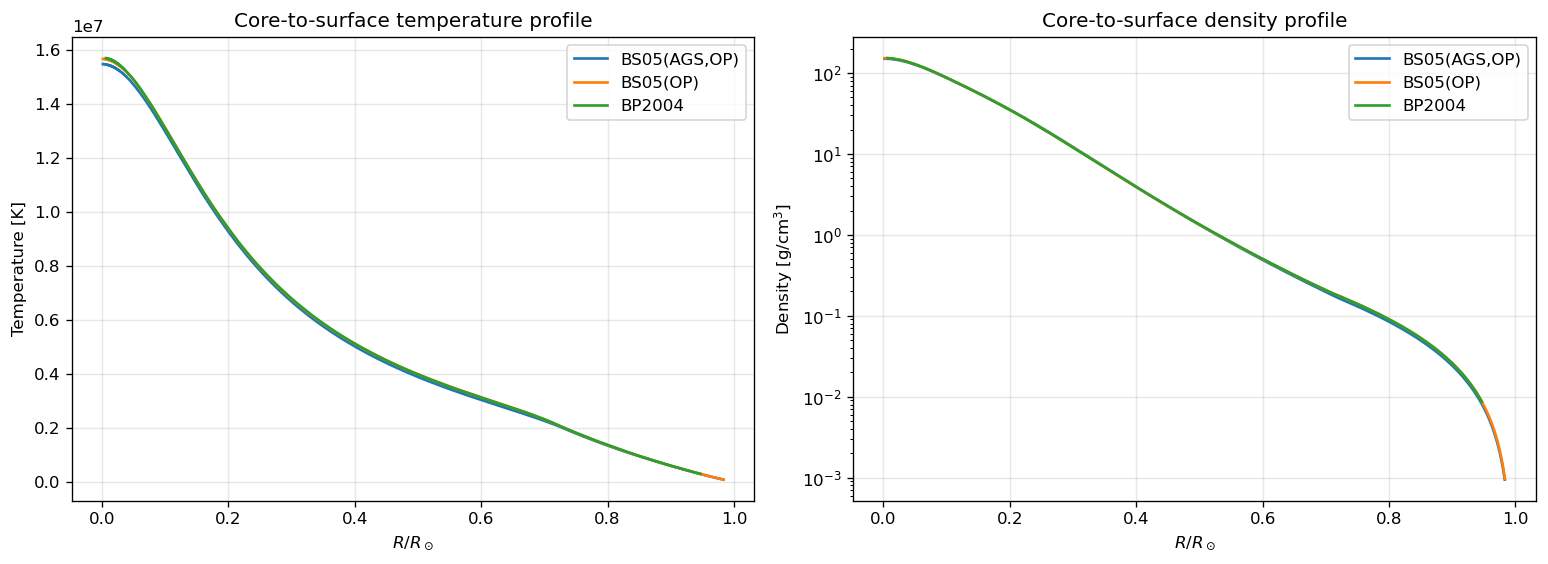

v:\output\external\bahcall\Bahcall_EDA_fig4_1_temperature_density.png
BS05(AGS,OP)  : T_c=1.548e+07 K   rho_c=1.505e+02 g/cm^3
BS05(OP)      : T_c=1.567e+07 K   rho_c=1.529e+02 g/cm^3
BP2004        : T_c=1.570e+07 K   rho_c=1.531e+02 g/cm^3


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8), sharex=True)
colors = {"BS05(AGS,OP)": "C0", "BS05(OP)": "C1", "BP2004": "C2"}

for name, df in models.items():
    axes[0].plot(df["R_Rsun"], df["T_K"], color=colors[name], lw=1.6, label=name)
    axes[1].plot(df["R_Rsun"], df["rho_gcm3"], color=colors[name], lw=1.6, label=name)

axes[0].set_ylabel("Temperature [K]")
axes[0].set_title("Core-to-surface temperature profile")
axes[1].set_ylabel(r"Density [g/cm$^3$]")
axes[1].set_yscale("log")
axes[1].set_title("Core-to-surface density profile")

for ax in axes:
    ax.set_xlabel(r"$R/R_\odot$")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.tight_layout()
save_and_show("Bahcall_EDA_fig4_1_temperature_density.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

for name, df in models.items():
    print(f"{name:14s}: T_c={df['T_K'].iloc[0]:.3e} K   rho_c={df['rho_gcm3'].iloc[0]:.3e} g/cm^3")

### 4.2 Chemical Composition Profiles

The hydrogen and helium-4 mass fractions trace core hydrogen burning
directly: hydrogen is depleted and helium-4 is enhanced toward the centre,
where nuclear burning has proceeded over the Sun's lifetime.

**Expected results:** $X(^1\mathrm{H})$ should be lowest in the core and rise
to the primordial-like envelope value; $Y(^4\mathrm{He})$ should show the
mirror-image trend.

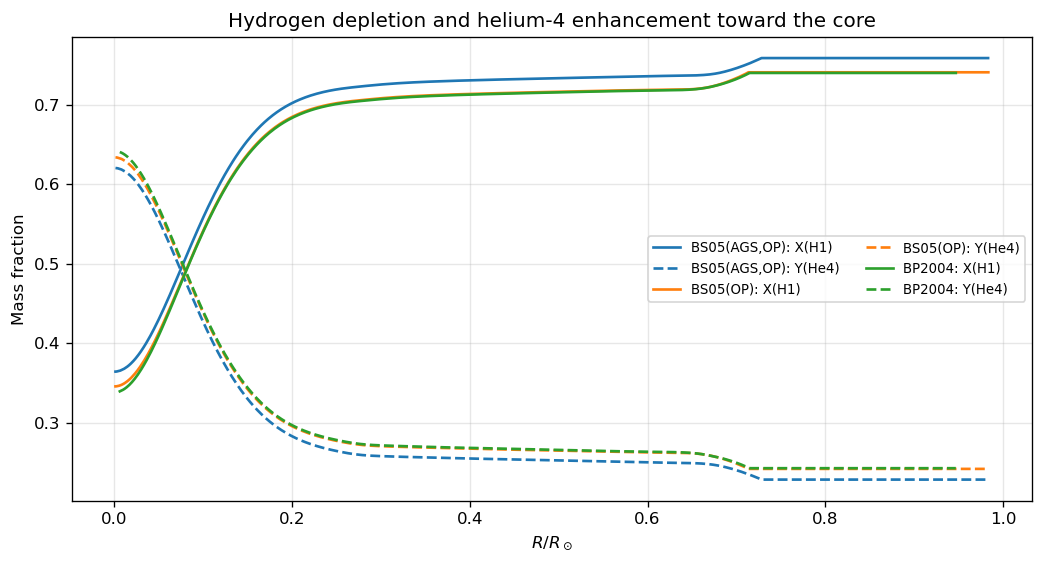

v:\output\external\bahcall\Bahcall_EDA_fig4_2_composition.png
BS05(AGS,OP)  : X(H1) core=0.3646  envelope=0.7583
BS05(OP)      : X(H1) core=0.3461  envelope=0.7405
BP2004        : X(H1) core=0.3398  envelope=0.7396


In [6]:
fig, ax = plt.subplots(figsize=(8.8, 4.8))
for name, df in models.items():
    ax.plot(df["R_Rsun"], df["X_H1"], color=colors[name], lw=1.6, label=f"{name}: X(H1)")
    ax.plot(df["R_Rsun"], df["Y_He4"], color=colors[name], lw=1.6, ls="--", label=f"{name}: Y(He4)")
ax.set_xlabel(r"$R/R_\odot$")
ax.set_ylabel("Mass fraction")
ax.set_title("Hydrogen depletion and helium-4 enhancement toward the core")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
save_and_show("Bahcall_EDA_fig4_2_composition.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

for name, df in models.items():
    print(f"{name:14s}: X(H1) core={df['X_H1'].iloc[0]:.4f}  envelope={df['X_H1'].iloc[-1]:.4f}")

## 5. Electron Density Profile

### 5.1 Dedicated Electron Density File

`nele_bs05op.dat` gives $\log_{10}(n_e/N_A)$ (electron density in units of
mol/cm$^3$, on a log10 scale) directly as a function of radius -- this is the
quantity that enters the MSW matter potential.

**Expected results:** $n_e$ should fall by many orders of magnitude from core
to surface (the log-scale axis should show an almost-linear decline over
most of the radius).

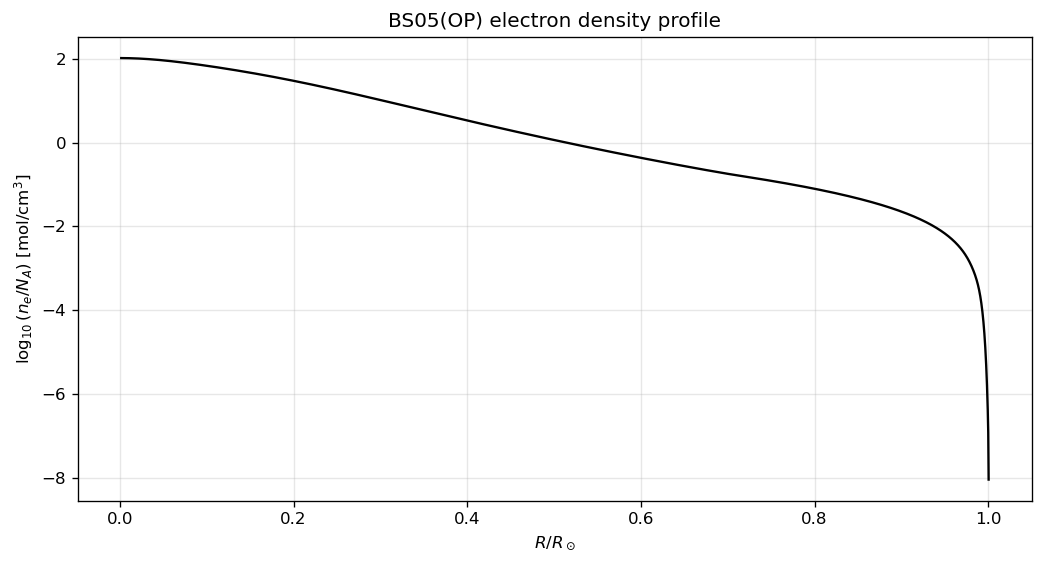

v:\output\external\bahcall\Bahcall_EDA_fig5_1_electron_density.png
log10(ne/NA) at core   : 2.0125
log10(ne/NA) at surface: -8.0351
implied dynamic range  : 1.116e+10x


In [7]:
fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.plot(nele["R_Rsun"], nele["log10_ne_over_NA"], lw=1.4, color="black")
ax.set_xlabel(r"$R/R_\odot$")
ax.set_ylabel(r"$\log_{10}(n_e/N_A)$ [mol/cm$^3$]")
ax.set_title("BS05(OP) electron density profile")
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_and_show("Bahcall_EDA_fig5_1_electron_density.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

print(f"log10(ne/NA) at core   : {nele['log10_ne_over_NA'].iloc[0]:.4f}")
print(f"log10(ne/NA) at surface: {nele['log10_ne_over_NA'].iloc[-1]:.4f}")
print(f"implied dynamic range  : {10**(nele['log10_ne_over_NA'].iloc[0] - nele['log10_ne_over_NA'].iloc[-1]):.3e}x")

### 5.2 Cross-Check Against the Flux-File Electron Density

The `*flux.dat` files independently tabulate `log10(n_e/N_A)` as column 3
(needed there to compute the production-weighted matter potential). This
should agree with the dedicated `nele_bs05op.dat` file for the same BS05(OP)
model, providing an internal consistency check on the downloaded dataset.

**Expected results:** the two BS05(OP) electron-density curves should overlap
almost exactly; the BS05(AGS,OP) and BP2004 curves should be close but not
identical, reflecting their different abundance/opacity choices.

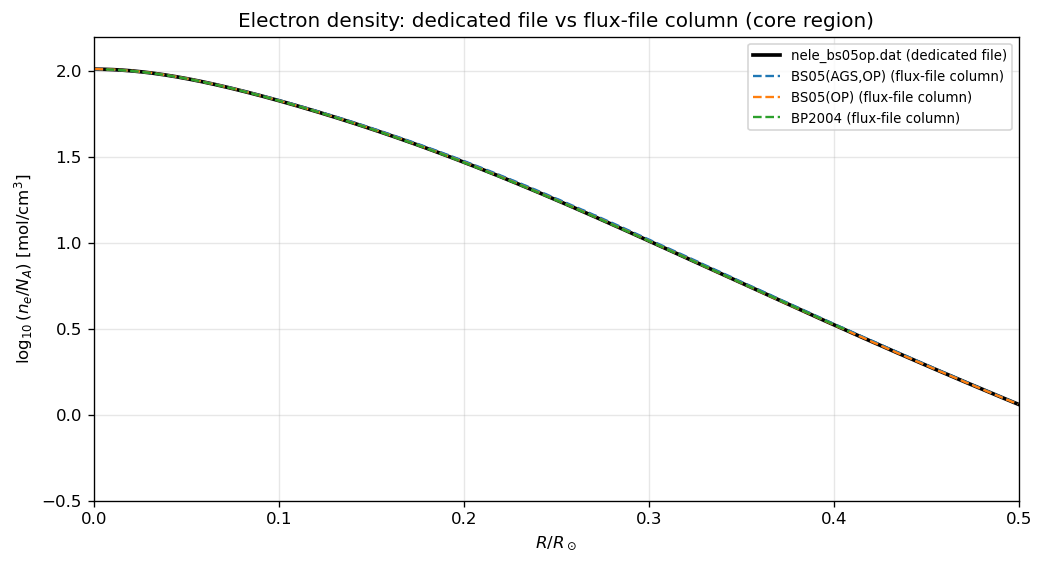

v:\output\external\bahcall\Bahcall_EDA_fig5_2_electron_density_crosscheck.png
max |dedicated - flux-file| log10(ne/NA) for BS05(OP), interpolated onto the flux grid: 0.0007


In [14]:
fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.plot(nele["R_Rsun"], nele["log10_ne_over_NA"], lw=2.2, color="black", label="nele_bs05op.dat (dedicated file)")
for name, df in fluxes.items():
    ax.plot(df["R_Rsun"], df["log10_ne_over_NA"], color=colors[name], lw=1.4, ls="--", label=f"{name} (flux-file column)")
ax.set_xlim(0.0, 0.5)
ax.set_xlabel(r"$R/R_\odot$")
ax.set_ylabel(r"$\log_{10}(n_e/N_A)$ [mol/cm$^3$]")
ax.set_title("Electron density: dedicated file vs flux-file column (core region)")
ax.set_ylim(-0.5,2.2)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
save_and_show("Bahcall_EDA_fig5_2_electron_density_crosscheck.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

nele_interp = np.interp(fluxes["BS05(OP)"]["R_Rsun"], nele["R_Rsun"], nele["log10_ne_over_NA"])
crosscheck_diff = float(np.max(np.abs(nele_interp - fluxes["BS05(OP)"]["log10_ne_over_NA"])))
print(f"max |dedicated - flux-file| log10(ne/NA) for BS05(OP), interpolated onto the flux grid: {crosscheck_diff:.4f}")

## 6. Solar Neutrino Production-Point Distributions

### 6.1 pp and 8B Production Profiles

The pp reaction (low temperature sensitivity) and 8B (extremely temperature-
sensitive, part of a rare side branch of the pp chain) bracket the range of
production-profile shapes: pp neutrinos come from a broad region of the core,
while 8B neutrinos come from a much more sharply peaked central region.

**Expected results:** the 8B production-fraction profile should peak at a
smaller radius and be narrower than the pp profile.

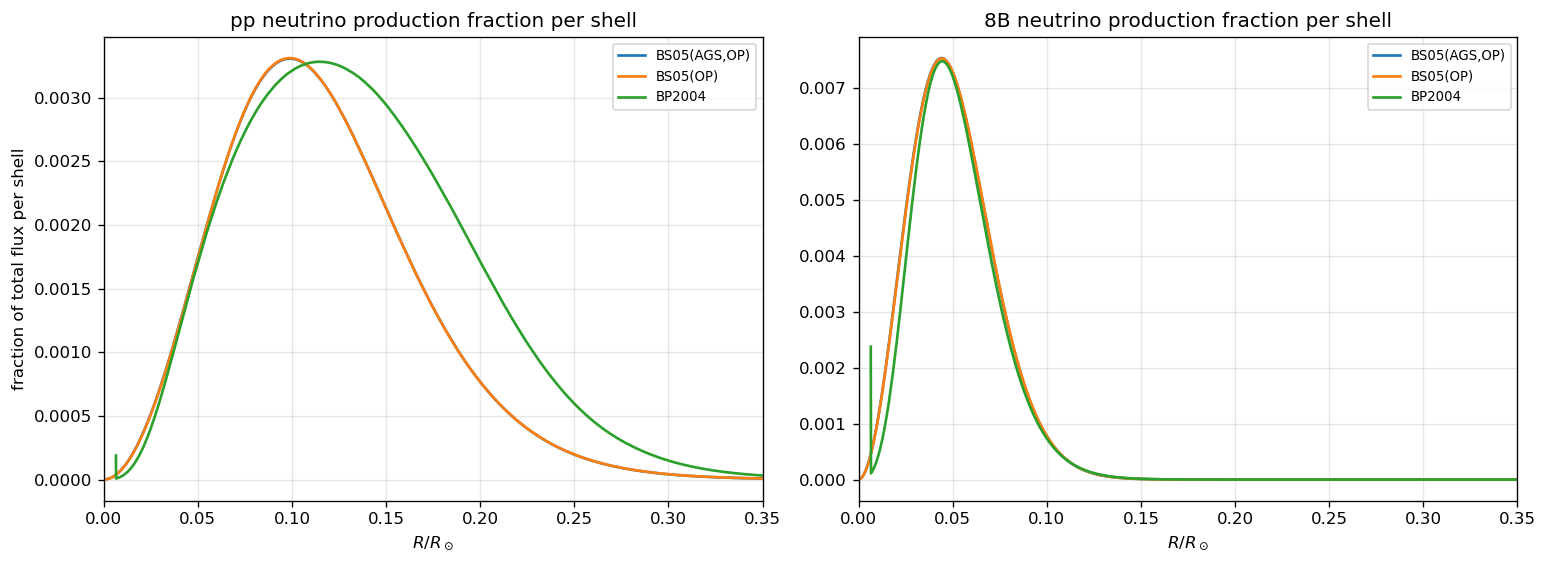

v:\output\external\bahcall\Bahcall_EDA_fig6_1_pp_8B_production.png
BS05(AGS,OP)  : pp peak at R=0.0988 R_sun   8B peak at R=0.0443 R_sun
BS05(OP)      : pp peak at R=0.0979 R_sun   8B peak at R=0.0439 R_sun
BP2004        : pp peak at R=0.1136 R_sun   8B peak at R=0.0444 R_sun


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8), sharex=True)

for name, df in fluxes.items():
    axes[0].plot(df["R_Rsun"], df["frac_pp"], color=colors[name], lw=1.6, label=name)
    axes[1].plot(df["R_Rsun"], df["frac_8B"], color=colors[name], lw=1.6, label=name)

axes[0].set_title("pp neutrino production fraction per shell")
axes[1].set_title("8B neutrino production fraction per shell")
for ax in axes:
    ax.set_xlabel(r"$R/R_\odot$")
    ax.set_xlim(0.0, 0.35)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
axes[0].set_ylabel("fraction of total flux per shell")

fig.tight_layout()
save_and_show("Bahcall_EDA_fig6_1_pp_8B_production.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

for name, df in fluxes.items():
    r_peak_pp = float(df.loc[df["frac_pp"].idxmax(), "R_Rsun"])
    r_peak_8b = float(df.loc[df["frac_8B"].idxmax(), "R_Rsun"])
    print(f"{name:14s}: pp peak at R={r_peak_pp:.4f} R_sun   8B peak at R={r_peak_8b:.4f} R_sun")

### 6.2 Be7, pep, CNO, and hep Production Profiles

The remaining pp-chain branches (7Be, pep, hep) and the three CNO-cycle
species (13N, 15O, 17F) fill out the full picture of where each neutrino
source originates.

**Expected results:** 7Be and pep should peak at similarly small radii to
8B (all three are comparably temperature-sensitive); the CNO species, being
even more temperature-sensitive than 8B, should peak at radii at or slightly
inside the 8B peak -- not at some intermediate radius between pp and 8B.

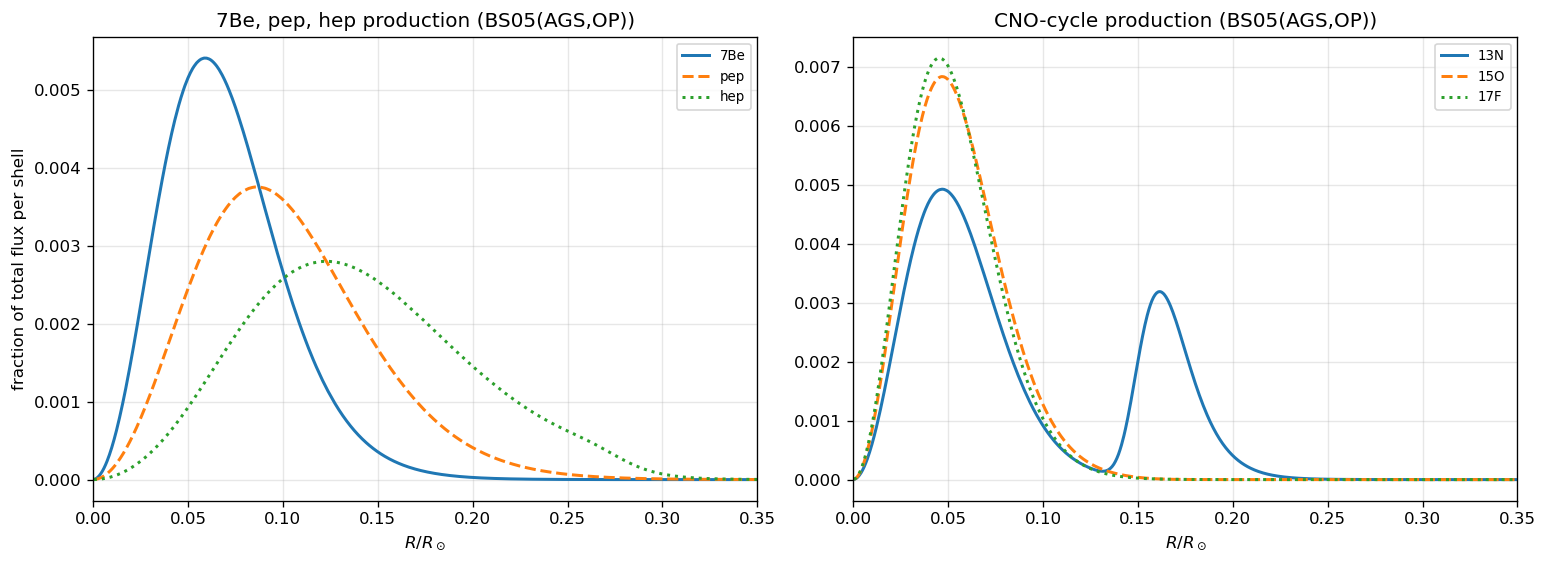

v:\output\external\bahcall\Bahcall_EDA_fig6_2_other_species_production.png
7Be  production peaks at R=0.0586 R_sun (BS05(AGS,OP))
pep  production peaks at R=0.0861 R_sun (BS05(AGS,OP))
hep  production peaks at R=0.1217 R_sun (BS05(AGS,OP))
13N  production peaks at R=0.0467 R_sun (BS05(AGS,OP))
15O  production peaks at R=0.0467 R_sun (BS05(AGS,OP))
17F  production peaks at R=0.0451 R_sun (BS05(AGS,OP))


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8), sharex=True)

model_for_species_plot = fluxes["BS05(AGS,OP)"]
for species, style in zip(["7Be", "pep", "hep"], ["-", "--", ":"]):
    axes[0].plot(model_for_species_plot["R_Rsun"], model_for_species_plot[f"frac_{species}"], ls=style, lw=1.8, label=species)
for species, style in zip(["13N", "15O", "17F"], ["-", "--", ":"]):
    axes[1].plot(model_for_species_plot["R_Rsun"], model_for_species_plot[f"frac_{species}"], ls=style, lw=1.8, label=species)

axes[0].set_title("7Be, pep, hep production (BS05(AGS,OP))")
axes[1].set_title("CNO-cycle production (BS05(AGS,OP))")
for ax in axes:
    ax.set_xlabel(r"$R/R_\odot$")
    ax.set_xlim(0.0, 0.35)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
axes[0].set_ylabel("fraction of total flux per shell")

fig.tight_layout()
save_and_show("Bahcall_EDA_fig6_2_other_species_production.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

for species in ["7Be", "pep", "hep", "13N", "15O", "17F"]:
    r_peak = float(model_for_species_plot.loc[model_for_species_plot[f"frac_{species}"].idxmax(), "R_Rsun"])
    print(f"{species:4s} production peaks at R={r_peak:.4f} R_sun (BS05(AGS,OP))")

## 7. Total Flux Normalizations

Each `*flux.dat` file's header line gives the total (radius-integrated)
neutrino flux normalization for each of the 8 species, in units of
$10^{10}\,\mathrm{cm}^{-2}\mathrm{s}^{-1}$ (pp, 7Be, pep) or
$10^{6-8}\,\mathrm{cm}^{-2}\mathrm{s}^{-1}$ (8B, 13N, 15O, 17F, hep) as
conventionally quoted in the SSM literature.

**Expected results:** pp should be by far the largest flux, 8B by far the
smallest of the "high-energy" channels among these three models; the two
BS05 variants should be closer to each other than either is to BP2004.

,pp,8B,13N,15O,17F,7Be,pep,hep
"BS05(AGS,OP)",6.058,0.01453,8.254000e-07,0.4338,0.000451,0.02007,0.01445,0.000325
BS05(OP),5.991,0.01421,7.930000e-07,0.4844,0.000569,0.03066,0.02331,0.000584
BP2004,5.938,0.01401,7.875000e-07,0.4857,0.000582,0.05712,0.05031,0.000591


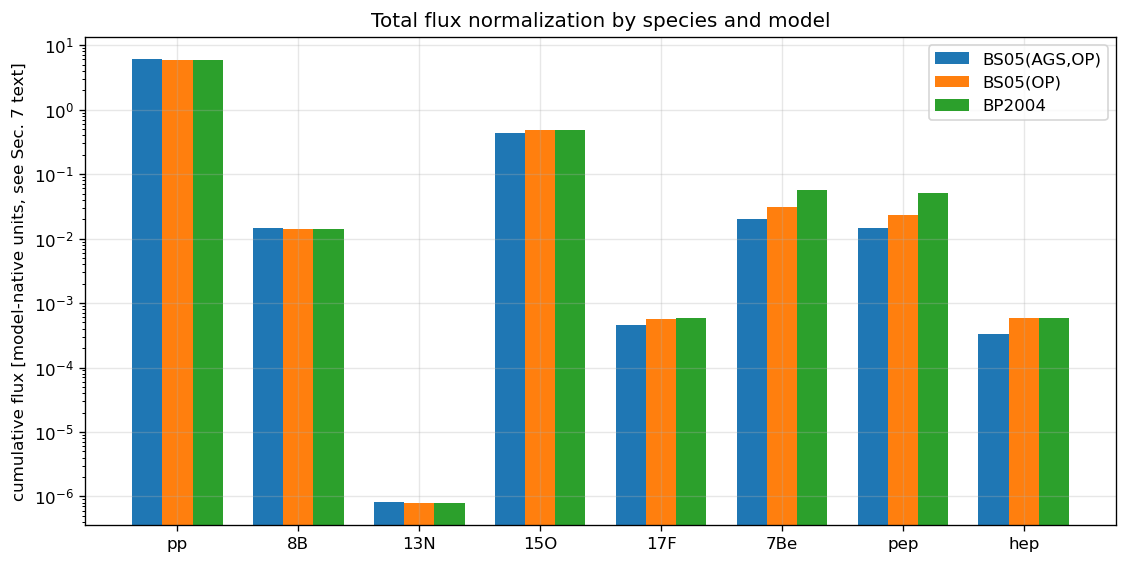

v:\output\external\bahcall\Bahcall_EDA_fig7_1_total_flux_normalizations.png


In [11]:
cumulative_table = pd.DataFrame(cumulative_fluxes).T
display(cumulative_table)

fig, ax = plt.subplots(figsize=(9.5, 4.8))
x = np.arange(len(FLUX_SPECIES))
width = 0.25
for i, (name, row) in enumerate(cumulative_fluxes.items()):
    ax.bar(x + (i - 1) * width, row.values, width=width, label=name, color=colors[name])
ax.set_xticks(x)
ax.set_xticklabels(FLUX_SPECIES)
ax.set_yscale("log")
ax.set_ylabel("cumulative flux [model-native units, see Sec. 7 text]")
ax.set_title("Total flux normalization by species and model")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()
fig.tight_layout()
save_and_show("Bahcall_EDA_fig7_1_total_flux_normalizations.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 8. Cross-Model Comparison Summary

A compact side-by-side comparison of core conditions and production-peak
radii across all three models.

**Expected results:** all three models should agree at the percent level in
their core temperature and density, with small systematic offsets between
the AGS,OP and OP abundance variants (and a larger offset relative to the
older BP2004 model), consistent with Section 4.

In [12]:
comparison_rows = []
for name in models:
    model_df = models[name]
    flux_df = fluxes[name]
    comparison_rows.append({
        "model": name,
        "T_core_K": model_df["T_K"].iloc[0],
        "rho_core_gcm3": model_df["rho_gcm3"].iloc[0],
        "X_H1_core": model_df["X_H1"].iloc[0],
        "pp_peak_R": float(flux_df.loc[flux_df["frac_pp"].idxmax(), "R_Rsun"]),
        "8B_peak_R": float(flux_df.loc[flux_df["frac_8B"].idxmax(), "R_Rsun"]),
        "pp_flux_cumulative": cumulative_fluxes[name]["pp"],
        "8B_flux_cumulative": cumulative_fluxes[name]["8B"],
    })
comparison = pd.DataFrame(comparison_rows).set_index("model")
display(comparison)

relative_to_agsop = (comparison - comparison.loc["BS05(AGS,OP)"]) / comparison.loc["BS05(AGS,OP)"]
print("\nFractional difference relative to BS05(AGS,OP):")
display(relative_to_agsop)

,T_core_K,rho_core_gcm3,X_H1_core,pp_peak_R,8B_peak_R,pp_flux_cumulative,8B_flux_cumulative
model,,,,,,,
"BS05(AGS,OP)",15480000.0,150.5,0.36462,0.09877,0.04426,6.058,0.01453
BS05(OP),15670000.0,152.9,0.34608,0.09795,0.04385,5.991,0.01421
BP2004,15700000.0,153.1,0.33984,0.11363,0.04440,5.938,0.01401



Fractional difference relative to BS05(AGS,OP):


,T_core_K,rho_core_gcm3,X_H1_core,pp_peak_R,8B_peak_R,pp_flux_cumulative,8B_flux_cumulative
model,,,,,,,
"BS05(AGS,OP)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
BS05(OP),0.012274,0.015947,-0.050847,-0.008302,-0.009263,-0.011060,-0.022023
BP2004,0.014212,0.017276,-0.067961,0.150451,0.003163,-0.019809,-0.035788


## 9. Summary

The local `data/external/Bahcall` files reproduce standard solar model and
solar-neutrino production tables for three model variants -- BS05(AGS,OP),
BS05(OP), and BP2004 -- downloaded from
[sns.ias.edu/~jnb/SNdata](https://www.sns.ias.edu/~jnb/SNdata/sndata.html)
(Bahcall, Serenelli & Basu 2005, `astro-ph/0412440`; Bahcall & Pinsonneault
2004, `astro-ph/0402114`).

The EDA confirms the expected physical structure: temperature and density
fall smoothly from the core to the photosphere, hydrogen is depleted and
helium-4 enhanced toward the centre from a solar lifetime of core burning,
and the electron density spans many orders of magnitude across the star. The
production-point distributions show the expected ordering in how centrally
concentrated each neutrino species is -- 8B, 7Be, and pep are sharply peaked
near the core, the CNO species peak at an intermediate radius, and pp is
produced over the broadest region -- consistent with each reaction's known
temperature sensitivity. The dedicated electron-density file and the
electron-density column embedded in the BS05(OP) flux file agree closely,
providing an internal consistency check on the downloaded dataset. The three
model variants agree closely in their core conditions, with the two BS05
abundance variants closer to each other than either is to the older BP2004
model.

These tables are suitable for downstream comparison against this project's
own solar density and production-point profiles (`medium.solar`,
`data/solar/flux/`), and against the BS05-based profiles nuSQuIDS itself
bundles for its `SunASnu` body (see the discussion of solar-model provenance
in `notebooks/validation/nusquids/nusquids2_SolarNeutrino.ipynb`).